In [1]:
pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 127.9 MB/s eta 0:00:00


In [2]:
import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
from skimage import data
from skimage.util import montage
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps

import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.utils import plot_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam

from scipy.spatial.distance import directed_hausdorff
from scipy.ndimage import binary_erosion, generate_binary_structure
from scipy.spatial.distance import cdist

np.set_printoptions(precision=3, suppress=True)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

import matplotlib
matplotlib.use("module://ipykernel.pylab.backend_inline")
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

print("TensorFlow:", tf.__version__)
print("Keras:     ", tf.keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
tf.keras.backend.set_floatx("float32")

SAVE_DIR = "/content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81"
os.makedirs(SAVE_DIR, exist_ok=True)



TensorFlow: 2.19.0
Keras:      3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Paths & Configuration

BEST_MODEL_PATH   = os.path.join(SAVE_DIR, "best_model.keras")
LAST_WEIGHTS_PATH = os.path.join(SAVE_DIR, "last.weights.h5")
LOG_PATH          = os.path.join(SAVE_DIR, "history.csv")
CURVES_PATH       = os.path.join(SAVE_DIR, "training_curves.png")
PREDS_PATH        = os.path.join(SAVE_DIR, "predictions.png")
EVAL_PATH         = os.path.join(SAVE_DIR, "evaluation_results.txt")
#DIST_PATH         = os.path.join(SAVE_DIR, "voxel_distributions.png")
#TIER_FIG_PATH     = os.path.join(SAVE_DIR, "tier_samples.png")
#BOXPLOT_PATH      = os.path.join(SAVE_DIR, "dice_boxplot.png")

IMG_HEIGHT    = 160
IMG_WIDTH     = 160
IN_CHANNELS   = 4
OUT_CHANNELS  = 3
BASE_FILTERS  = 64
GROUPS        = 8

BATCH_SIZE    = 16
EPOCHS        = 100
LEARNING_RATE = 1e-4
PATIENCE      = 10
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
SEED          = 42

WT_WEIGHT     = 0.5
ET_WEIGHT     = 2.0
TC_WEIGHT     = 1.5

KEEP_TIER_A   = 1.00
KEEP_TIER_B   = 0.60
KEEP_TIER_C   = 0.15
KEEP_TIER_D   = 0.05
MIN_ET_VOXELS = 5
MIN_TC_VOXELS = 10
MIN_WT_VOXELS = 10

CHANNEL_NAMES   = ["WT", "ET", "TC"]
CHANNEL_WEIGHTS = [WT_WEIGHT, ET_WEIGHT, TC_WEIGHT]

In [4]:
# save figure to Drive AND display inline

def save_and_show(fig, save_path, caption=""):
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved → {save_path}" + (f"  ({caption})" if caption else ""))

In [5]:
# Data Loading

from zipfile import ZipFile
with ZipFile('/content/drive/MyDrive/BRAIN2020_CORRECTED_NORMALIZED_CROPPED.zip', 'r') as z:
    z.extractall('/content/CROPPED2020')

BRAIN2020_CROPPED = "/content/CROPPED2020"


def create_multimodal_image(dataset_root_dir):
    modalities = ["t1", "t1ce", "t2", "flair"]
    data, grade = {}, {}
    for pid in os.listdir(dataset_root_dir):
        pd_ = os.path.join(dataset_root_dir, pid)
        if not os.path.isdir(pd_):
            continue
        imgs, ok = [], True
        for mod in modalities:
            fp = os.path.join(pd_, f"{pid}_{mod}_pre.nii")
            if not os.path.exists(fp):
                ok = False; break
            imgs.append(nib.load(fp).get_fdata().astype(np.float32))
        if ok:
            data[pid]  = np.stack(imgs, axis=-1)
            grade[pid] = "unknown"
    return data, grade


def create_combined_label_masks(seg_path):
    seg = nib.load(seg_path).get_fdata().astype(np.uint8)
    return np.stack([
        np.isin(seg, [1, 2, 4]).astype(np.float32),   # WT
        (seg == 4).astype(np.float32),                  # ET
        np.isin(seg, [1, 4]).astype(np.float32),        # TC
    ], axis=-1)


def load_all_patients(root):
    mdata, mgrade = create_multimodal_image(root)
    pids, grades, xvols, yvols = [], [], [], []
    for pid in mdata:
        sp = os.path.join(root, pid, f"{pid}_seg_pre.nii")
        if os.path.exists(sp):
            xv = mdata[pid]; yv = create_combined_label_masks(sp)
            if xv.shape[:3] == yv.shape[:3]:
                pids.append(pid); grades.append(mgrade[pid])
                xvols.append(xv);  yvols.append(yv)

    print(f"Loaded {len(xvols)} patients")
    return pids, grades, xvols, yvols


patient_ids, grades, X_volumes, Y_volumes = load_all_patients(BRAIN2020_CROPPED)

Loaded 369 patients


In [6]:
# Volume Cleaning

def clean_volumes(xvols):
    return [
        np.clip(np.nan_to_num(x, nan=0., posinf=0., neginf=0.), -5., 5.)
        for x in xvols
    ]

X_volumes = clean_volumes(X_volumes)

In [7]:
# Balanced Slice Extraction

def volumes_to_2d_slices_balanced(
    x_volumes, y_volumes,
    min_et_voxels=MIN_ET_VOXELS, min_tc_voxels=MIN_TC_VOXELS,
    min_wt_voxels=MIN_WT_VOXELS,
    keep_tier_a=KEEP_TIER_A, keep_tier_b=KEEP_TIER_B,
    keep_tier_c=KEEP_TIER_C, keep_tier_d=KEEP_TIER_D, seed=SEED,
):
    rng = np.random.default_rng(seed)
    xl, yl, tl = [], [], []
    counts = {t: 0 for t in ["A","B","C","D","A_skip","B_skip","C_skip","D_skip"]}
    for xv, yv in zip(x_volumes, y_volumes):
        for d in range(xv.shape[2]):
            xs = xv[:, :, d, :]; ys = yv[:, :, d, :]
            wt_fg = int(ys[..., 0].sum()) >= min_wt_voxels
            tc_fg = int(ys[..., 2].sum()) >= min_tc_voxels
            et_fg = int(ys[..., 1].sum()) >= min_et_voxels
            if   wt_fg and tc_fg and et_fg: tier, rate = "A", keep_tier_a
            elif wt_fg and tc_fg:           tier, rate = "B", keep_tier_b
            elif wt_fg:                     tier, rate = "C", keep_tier_c
            else:                           tier, rate = "D", keep_tier_d
            if rng.random() < rate:
                xl.append(xs); yl.append(ys); tl.append(tier)
                counts[tier] += 1
            else:
                counts[f"{tier}_skip"] += 1
    X = np.array(xl, np.float32); Y = np.array(yl, np.float32)
    descs = {"A":"WT+TC+ET","B":"WT+TC (no ET)","C":"WT only","D":"no fg"}
    print("\n" + "="*58)
    print("  Balanced Slice Extraction")
    print("="*58)
    for t in ["A","B","C","D"]:
        print(f"  Tier {t} ({descs[t]:<16}): "
              f"kept={counts[t]:5d}  skipped={counts[t+'_skip']:5d}")
    print(f"  Total: {len(X)}")
    print("="*58)
    return X, Y, tl


def print_slice_balance(Y, tier_labels, split_name="Dataset"):
    wt_v = Y[...,0].sum(axis=(1,2)); et_v = Y[...,1].sum(axis=(1,2))
    tc_v = Y[...,2].sum(axis=(1,2)); N = len(Y)
    tc = {t: tier_labels.count(t) for t in ["A","B","C","D"]}
    print(f"\n  [{split_name}]  {N} slices  "
          f"A={tc['A']} B={tc['B']} C={tc['C']} D={tc['D']}")
    for name, v in [("WT", wt_v), ("ET", et_v), ("TC", tc_v)]:
        print(f"    {name}: {(v>0).mean()*100:5.1f}% present  "
              f"mean={v.mean():.1f} vox")
    print(f"    Nesting: ET≤TC={(et_v<=tc_v+1).all()}  "
          f"TC≤WT={(tc_v<=wt_v+1).all()}")


X_sl, Y_sl, tier_labels = volumes_to_2d_slices_balanced(X_volumes, Y_volumes)
del X_volumes, Y_volumes
print_slice_balance(Y_sl, tier_labels, "Full balanced dataset")


  Balanced Slice Extraction
  Tier A (WT+TC+ET        ): kept=13874  skipped=    0
  Tier B (WT+TC (no ET)   ): kept= 1416  skipped=  984
  Tier C (WT only         ): kept= 1147  skipped= 6385
  Tier D (no fg           ): kept= 1167  skipped=22259
  Total: 17604

  [Full balanced dataset]  17604 slices  A=13874 B=1416 C=1147 D=1167
    WT:  93.5% present  mean=1758.4 vox
    ET:  79.7% present  mean=411.8 vox
    TC:  87.2% present  mean=821.4 vox
    Nesting: ET≤TC=True  TC≤WT=True


In [8]:
# Train / Val / Test Split  (70% / 15% / 15%)

X_trainval, X_test, Y_trainval, Y_test, tl_trainval, tl_test = train_test_split(
    X_sl, Y_sl, tier_labels,
    test_size=TEST_SPLIT, random_state=SEED, shuffle=True
)


val_fraction_of_trainval = VAL_SPLIT / (1.0 - TEST_SPLIT)

X_train, X_val, Y_train, Y_val, tl_train, tl_val = train_test_split(
    X_trainval, Y_trainval, tl_trainval,
    test_size=val_fraction_of_trainval, random_state=SEED, shuffle=True
)

del X_sl, Y_sl, X_trainval, Y_trainval

print("\nAfter split:")
print_slice_balance(Y_train, tl_train, "Train  (~70%)")
print_slice_balance(Y_val,   tl_val,   "Val    (~15%)")
print_slice_balance(Y_test,  tl_test,  "Test   (~15%)")
print(f"\nTrain : {X_train.shape}"
      f"\nVal   : {X_val.shape}"
      f"\nTest  : {X_test.shape}")


After split:

  [Train  (~70%)]  12322 slices  A=9706 B=1002 C=786 D=828
    WT:  93.5% present  mean=1766.6 vox
    ET:  79.7% present  mean=411.7 vox
    TC:  87.3% present  mean=821.3 vox
    Nesting: ET≤TC=True  TC≤WT=True

  [Val    (~15%)]  2641 slices  A=2111 B=198 C=172 D=160
    WT:  94.1% present  mean=1774.0 vox
    ET:  80.7% present  mean=418.3 vox
    TC:  87.7% present  mean=835.1 vox
    Nesting: ET≤TC=True  TC≤WT=True

  [Test   (~15%)]  2641 slices  A=2057 B=216 C=189 D=179
    WT:  93.3% present  mean=1705.0 vox
    ET:  78.8% present  mean=405.9 vox
    TC:  86.4% present  mean=808.1 vox
    Nesting: ET≤TC=True  TC≤WT=True

Train : (12322, 160, 160, 4)
Val   : (2641, 160, 160, 4)
Test  : (2641, 160, 160, 4)


In [9]:
# tf.data Pipeline

AUTOTUNE = tf.data.AUTOTUNE


def augment(img, msk):

    # Zoom (±20%)
    zoom = tf.random.uniform([], 0.8, 1.2)

    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    new_h = tf.cast(tf.cast(h, tf.float32) * zoom, tf.int32)
    new_w = tf.cast(tf.cast(w, tf.float32) * zoom, tf.int32)

    img = tf.image.resize(img, (new_h, new_w), method='bilinear')
    msk = tf.image.resize(msk, (new_h, new_w), method='nearest')

    img = tf.image.resize_with_crop_or_pad(img, h, w)
    msk = tf.image.resize_with_crop_or_pad(msk, h, w)


    # Width & Height Shift (±20%)
    max_dx = tf.cast(0.2 * tf.cast(w, tf.float32), tf.int32)
    max_dy = tf.cast(0.2 * tf.cast(h, tf.float32), tf.int32)

    dx = tf.random.uniform([], -max_dx, max_dx, dtype=tf.int32)
    dy = tf.random.uniform([], -max_dy, max_dy, dtype=tf.int32)

    img = tf.roll(img, shift=[dy, dx], axis=[0, 1])
    msk = tf.roll(msk, shift=[dy, dx], axis=[0, 1])

    #Flip
    if tf.random.uniform(()) > 0.2:
      img = tf.image.flip_left_right(img)
      msk = tf.image.flip_left_right(msk)
    if tf.random.uniform(()) > 0.2:
      img = tf.image.flip_up_down(img)
      msk = tf.image.flip_up_down(msk)

    return img, msk


def make_dataset(X, Y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED).map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = make_dataset(X_train, Y_train, training=True)
val_ds   = make_dataset(X_val,   Y_val,   training=False)
test_ds  = make_dataset(X_test,  Y_test,  training=False)

print(f"\nTrain batches : {len(train_ds)}"
      f"\nVal   batches : {len(val_ds)}"
      f"\nTest  batches : {len(test_ds)}")


Train batches : 771
Val   batches : 166
Test  batches : 166


In [10]:
# U-Net Architecture

def conv_block(x, filters, groups=GROUPS):

    for _ in range(2):
        x = layers.Conv2D(
            filters, 3, padding="same", use_bias=False,
            kernel_initializer="he_normal"
        )(x)
        x = layers.GroupNormalization(groups=groups)(x)
        x = layers.Activation("relu")(x)
    return x


def encoder_block(x, filters):

    skip = conv_block(x, filters)
    pool = layers.MaxPooling2D(2)(skip)
    return skip, pool


def decoder_block(x, skip, filters):

    x = layers.Conv2DTranspose(
        filters, 2, strides=2, padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(
    img_height=IMG_HEIGHT, img_width=IMG_WIDTH,
    in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS,
    base_filters=BASE_FILTERS, dropout_rate=0.3
):

    inputs = layers.Input(
        shape=(img_height, img_width, in_channels), name="input"
    )

    # ── Encoder ────────────────────────────────────────────────────────────
    s1, p1 = encoder_block(inputs, base_filters)         # filters=64
    s2, p2 = encoder_block(p1,     base_filters * 2)     # filters=128
    s3, p3 = encoder_block(p2,     base_filters * 4)     # filters=256
    s4, p4 = encoder_block(p3,     base_filters * 8)     # filters=512

    # ── Bottleneck ─────────────────────────────────────────────────────────
    b = conv_block(p4, base_filters * 16)                # filters=1024
    b = layers.Dropout(dropout_rate)(b)

    # ── Decoder ────────────────────────────────────────────────────────────
    d4 = decoder_block(b,  s4, base_filters * 8)         # filters=512
    d3 = decoder_block(d4, s3, base_filters * 4)         # filters=256
    d2 = decoder_block(d3, s2, base_filters * 2)         # filters=128
    d1 = decoder_block(d2, s1, base_filters)             # filters=64

    # ── Output ────────────────────────────────────────────────────────
    outputs = layers.Conv2D(
        out_channels, 1, activation="sigmoid", name="output"
    )(d1)

    return Model(inputs, outputs, name="UNet_2D")


model = build_unet()
model.summary()

Model: "UNet_2D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 160, 160,  │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 160, 160,  │      2,304 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalization │ (None, 160, 160,  │        128 │ conv2d[0][0]      │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 160, 160,  │          0 │ group_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 160, 160,  │     36,864 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 160, 160,  │        128 │ conv2d_1[0][0]    │
│ (GroupNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 160, 160,  │          0 │ group_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 80, 80,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 80, 80,    │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_2[0][0]    │
│ (GroupNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 80, 80,    │          0 │ group_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 80, 80,    │    147,456 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 80, 80,    │        256 │ conv2d_3[0][0]    │
│ (GroupNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 80, 80,    │          0 │ group_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 40, 40,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 40, 40,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ group_normalizatio… │ (None, 40, 40,    │        512 │ conv2d_4[0][0]  

 Total params: 31,038,339 (118.40 MB)

 Trainable params: 31,038,339 (118.40 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Loss Function

def _boundary_weight_map(y_true_ch, pool_size=11, border_weight=3.0):

    averaged = tf.nn.avg_pool2d(
        y_true_ch,
        ksize=pool_size,
        strides=1,
        padding="SAME"
    )                                      # (B, H, W, 1)

    border = tf.cast(averaged > 0.005, tf.float32) * \
             tf.cast(averaged < 0.995, tf.float32)   # (B, H, W, 1)

    weight  = tf.ones_like(averaged)
    w0      = tf.reduce_sum(weight)
    weight  = weight + border * (border_weight - 1.0)
    w1      = tf.reduce_sum(weight)

    weight  = weight * (w0 / (w1 + 1e-8))
    return weight


def _weighted_bce_channel(y_true_ch, y_pred_ch, weight):

    epsilon   = 1e-7
    y_pred_ch = tf.clip_by_value(y_pred_ch, epsilon, 1.0 - epsilon)
    logit     = tf.math.log(y_pred_ch / (1.0 - y_pred_ch))

    bce = ((1.0 - y_true_ch) * logit
           + (1.0 + (weight - 1.0) * y_true_ch)
           * (tf.math.log(1.0 + tf.exp(-tf.abs(logit)))
              + tf.maximum(-logit, 0.0)))

    return tf.reduce_sum(bce) / (tf.reduce_sum(weight) + 1e-8)


def _weighted_dice_channel(y_true_ch, y_pred_ch, weight, smooth=1.0):

    w   = weight * weight
    m1  = y_true_ch
    m2  = y_pred_ch
    intersection = tf.reduce_sum(w * m1 * m2)
    denom        = tf.reduce_sum(w * (m1 ** 2)) + tf.reduce_sum(w * (m2 ** 2))
    score        = (2.0 * intersection + smooth) / (denom + smooth)
    return 1.0 - score


def weighted_boundary_loss_fn(
    wt_weight   = WT_WEIGHT,    # 1.0
    et_weight   = ET_WEIGHT,    # 2.0
    tc_weight   = TC_WEIGHT,    # 1.5
    pool_size   = 11,
    border_mult = 3.0,
    bce_frac    = 0.5,
):

    channel_weights = tf.constant(
        [wt_weight, et_weight, tc_weight], dtype=tf.float32)
    total_w = wt_weight + et_weight + tc_weight

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1 - 1e-7)

        channel_losses = []
        for ch in range(3):
            y_t_ch = tf.expand_dims(y_true[..., ch], axis=-1)  # (B,H,W,1)
            y_p_ch = tf.expand_dims(y_pred[..., ch], axis=-1)

            w_map = _boundary_weight_map(y_t_ch, pool_size, border_mult)

            bce  = _weighted_bce_channel( y_t_ch, y_p_ch, w_map)
            dice = _weighted_dice_channel(y_t_ch, y_p_ch, w_map)

            ch_loss = bce_frac * bce + (1.0 - bce_frac) * dice
            channel_losses.append(ch_loss * channel_weights[ch])

        return tf.reduce_sum(tf.stack(channel_losses)) / total_w

    loss.__name__ = "weighted_boundary_loss"
    return loss


loss_fn = weighted_boundary_loss_fn()

# ── Pre-training loss check ────────────────────────────────────────────────────
print("\nLoss function: Weighted Boundary-Aware BCE + Dice")
print(f"  pool_size={11}  border_mult=3.0  bce_frac=0.5")
print(f"  Channel weights: WT={WT_WEIGHT}  ET={ET_WEIGHT}  TC={TC_WEIGHT}")

for xb, yb in train_ds.take(1):
    out = model(xb, training=False)
    lv  = loss_fn(yb, out).numpy()
    print(f"\nPre-training check:  loss={lv:.4f}  "
          f"NaN={np.isnan(out.numpy()).any()}")


Loss function: Weighted Boundary-Aware BCE + Dice
  pool_size=11  border_mult=3.0  bce_frac=0.5
  Channel weights: WT=0.5  ET=0.5  TC=0.5

Pre-training check:  loss=0.8656  NaN=False


In [12]:
# Metrics

def soft_dice_per_channel(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    axes         = [1, 2]
    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)   # (B, C)
    denom        = tf.reduce_sum(y_true + y_pred, axis=axes)   # (B, C)
    return (2.0 * intersection + smooth) / (denom + smooth)    # (B, C)


def dice_WT(y_true, y_pred, smooth=1e-6):
    return tf.reduce_mean(
        soft_dice_per_channel(y_true[..., 0:1], y_pred[..., 0:1], smooth)
    )

def dice_ET(y_true, y_pred, smooth=1e-6):
    return tf.reduce_mean(
        soft_dice_per_channel(y_true[..., 1:2], y_pred[..., 1:2], smooth)
    )

def dice_TC(y_true, y_pred, smooth=1e-6):
    return tf.reduce_mean(
        soft_dice_per_channel(y_true[..., 2:3], y_pred[..., 2:3], smooth)
    )

def dice_mean(y_true, y_pred, smooth=1e-6):
    return (dice_WT(y_true, y_pred, smooth) +
            dice_ET(y_true, y_pred, smooth) +
            dice_TC(y_true, y_pred, smooth)) / 3.0

def make_metrics():
    return [
        tf.keras.metrics.MeanMetricWrapper(dice_WT,   name="dice_WT"),
        tf.keras.metrics.MeanMetricWrapper(dice_ET,   name="dice_ET"),
        tf.keras.metrics.MeanMetricWrapper(dice_TC,   name="dice_TC"),
        tf.keras.metrics.MeanMetricWrapper(dice_mean, name="mean_dice"),
    ]


# ── Metric sanity check ────────────────────────────────────────────────────
print("\nMetric check ...")
_m = make_metrics()
for xb, yb in train_ds.take(1):
    _out = model(xb, training=False)
    for m in _m:
        m.update_state(yb, _out)
        print(f"  {m.name:<15} = {m.result().numpy():.4f}")
        m.reset_state()
del _m, _out


Metric check ...
  dice_WT         = 0.0676
  dice_ET         = 0.0227
  dice_TC         = 0.0584
  mean_dice       = 0.0496


In [13]:
# Compile

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=make_metrics()
)

for xb, yb in train_ds.take(1):
    out = model(xb, training=False)
    lv  = loss_fn(yb, out).numpy()
    print(f"\nPre-training check:  loss={lv:.4f}  NaN={np.isnan(out.numpy()).any()}")


Pre-training check:  loss=0.8596  NaN=False


In [14]:
callbacks = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_mean_dice",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=LAST_WEIGHTS_PATH,
        save_weights_only=True,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_mean_dice",
        mode="max",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_mean_dice",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=0
    ),
    CSVLogger(LOG_PATH, append=True),
]

In [15]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - dice_ET: 0.4766 - dice_TC: 0.4716 - dice_WT: 0.6158 - loss: 0.2255 - mean_dice: 0.5213
Epoch 1: val_mean_dice improved from None to 0.72276, saving model to /content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81/best_model.keras
771/771 ━━━━━━━━━━━━━━━━━━━━ 125s 104ms/step - dice_ET: 0.5698 - dice_TC: 0.5795 - dice_WT: 0.7173 - loss: 0.1517 - mean_dice: 0.6222 - val_dice_ET: 0.6533 - val_dice_TC: 0.7085 - val_dice_WT: 0.8065 - val_loss: 0.0983 - val_mean_dice: 0.7228
Epoch 2/100
771/771 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - dice_ET: 0.6515 - dice_TC: 0.7005 - dice_WT: 0.7893 - loss: 0.0995 - mean_dice: 0.7138
Epoch 2: val_mean_dice improved from 0.72276 to 0.74753, saving model to /content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81/best_model.keras

Epoch 2: finished saving model to 

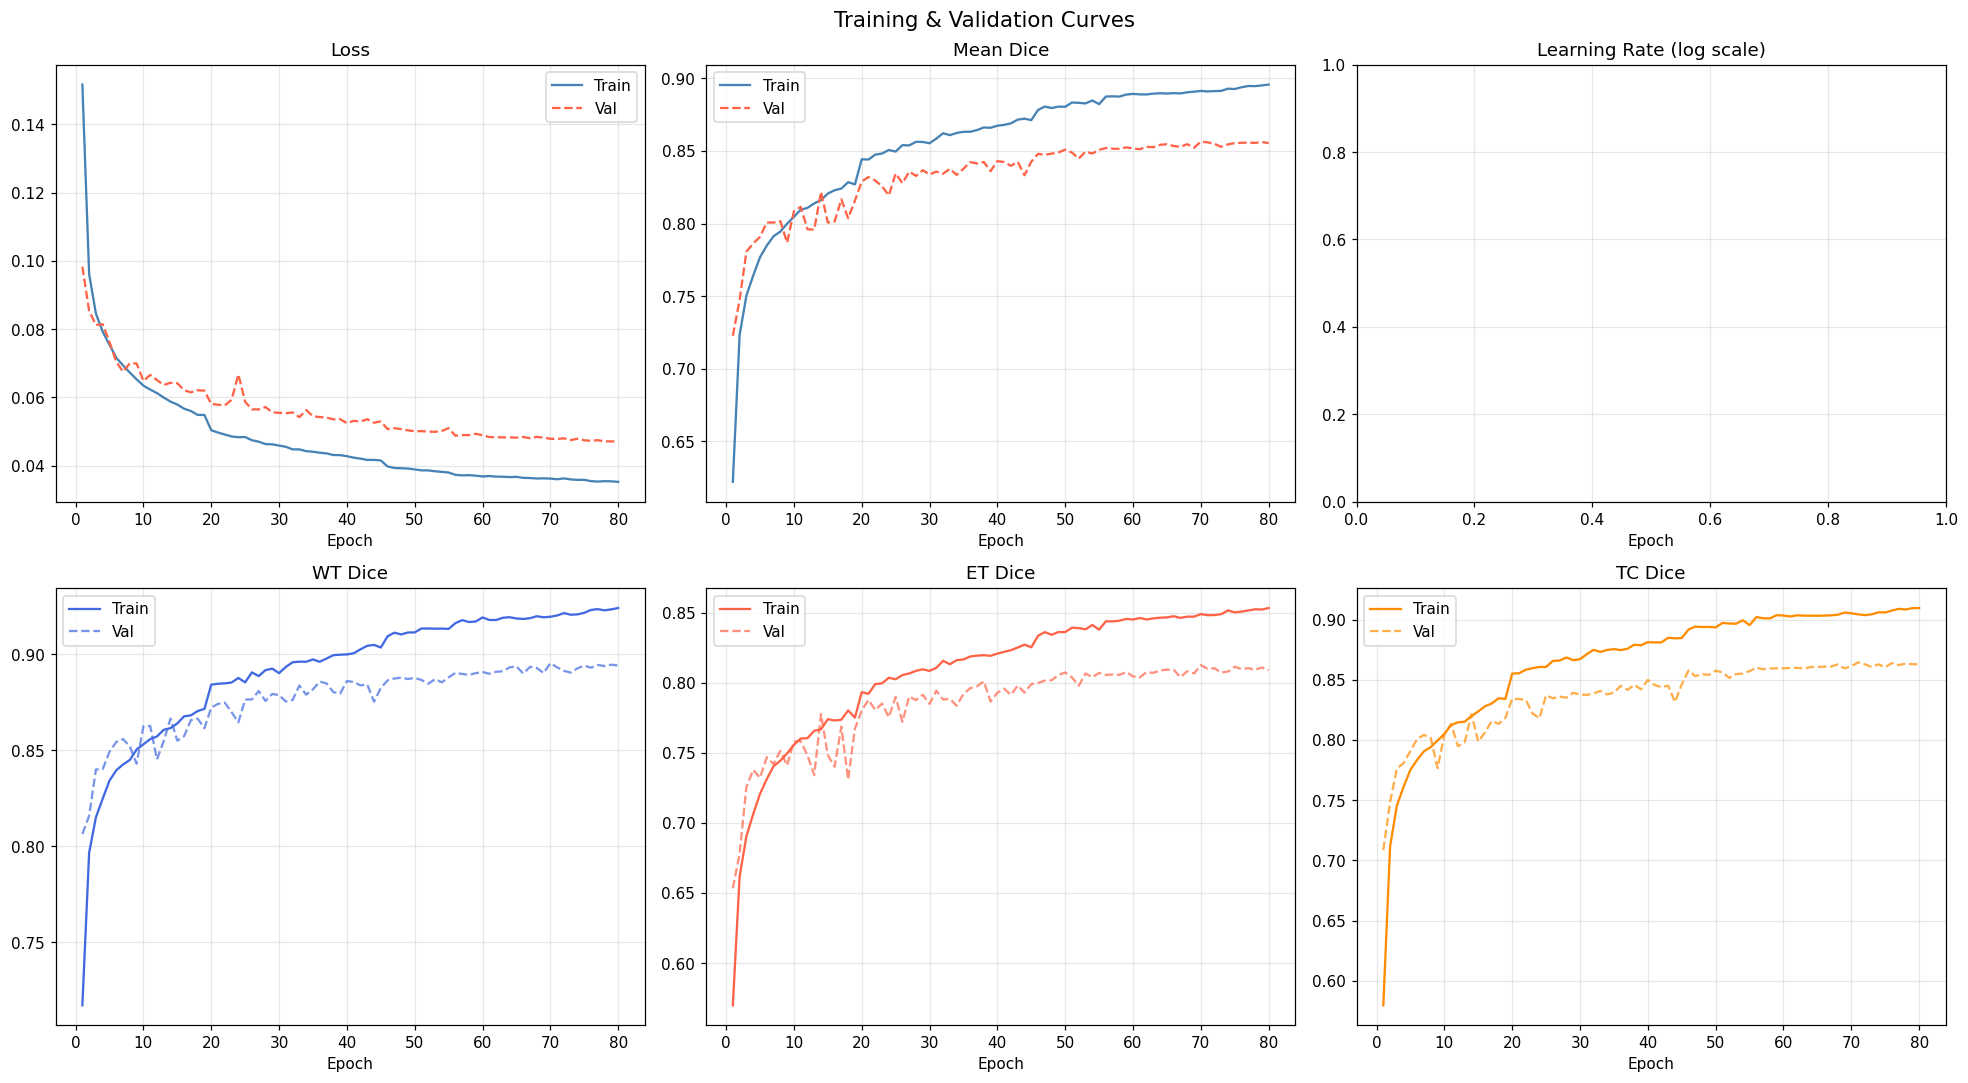

Saved → /content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81/training_curves.png  (training curves)


In [16]:
# Training Curves

def plot_training_curves(history, save_path):
    hist   = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training & Validation Curves", fontsize=14)

    # Loss
    ax = axes[0, 0]
    ax.plot(epochs, hist["loss"],     label="Train", color="steelblue")
    ax.plot(epochs, hist["val_loss"], label="Val",   color="tomato", linestyle="--")
    ax.set_title("Loss")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

    # Mean Dice
    ax = axes[0, 1]
    ax.plot(epochs, hist["mean_dice"],     label="Train", color="steelblue")
    ax.plot(epochs, hist["val_mean_dice"], label="Val",   color="tomato", linestyle="--")
    ax.set_title("Mean Dice")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

    # Learning rate
    ax = axes[0, 2]
    if "lr" in hist:
        ax.semilogy(epochs, hist["lr"], color="purple")
    ax.set_title("Learning Rate (log scale)")
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)

    # Per-region Dice
    region_cfg = [
        ("dice_WT", "val_dice_WT", "WT Dice", "royalblue"),
        ("dice_ET", "val_dice_ET", "ET Dice", "tomato"),
        ("dice_TC", "val_dice_TC", "TC Dice", "darkorange"),
    ]
    for idx, (tr_key, val_key, title, color) in enumerate(region_cfg):
        ax = axes[1, idx]
        if tr_key  in hist: ax.plot(epochs, hist[tr_key],  label="Train",
                                    color=color)
        if val_key in hist: ax.plot(epochs, hist[val_key], label="Val",
                                    color=color, linestyle="--", alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.3)

    fig.tight_layout()
    save_and_show(fig, save_path, "training curves")

plot_training_curves(history, CURVES_PATH)

In [17]:
# Evaluation on Test Set

print("\n" + "="*58)
print("  Evaluating on Test  (best model weights)")
print("="*58)

test_results = model.evaluate(test_ds, verbose=1)
metric_names = model.metrics_names

print("\n ")
print("   Test Evaluation:         ")

for name, val in zip(metric_names, test_results):
    print(f"  {name:<24s}: {val:.4f}  ")


with open(EVAL_PATH, "w") as f:
    f.write("=" * 52 + "\n")
    f.write("  Test Evaluation Results\n")
    f.write("=" * 52 + "\n")
    for name, val in zip(metric_names, test_results):
        f.write(f"  {name:<28s}: {val:.6f}\n")
    f.write("=" * 52 + "\n")

print(f"\nEvaluation results saved → {EVAL_PATH}")


  Evaluating on Test  (best model weights)
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - dice_ET: 0.8124 - dice_TC: 0.8551 - dice_WT: 0.8918 - loss: 0.0477 - mean_dice: 0.8531

 
   Test Evaluation:         
  loss                    : 0.0477  
  compile_metrics         : 0.8918  

Evaluation results saved → /content/drive/MyDrive/Training_models/Preprocessing/RAAGR2Net_Run81/evaluation_results.txt
